# Commercial Dimension — EDA

Exploratory analysis of the commercial feature matrix (`feature_matrix_commercial.csv`,
542 PLR × 60 features). Structure parallel to the real-estate dimension:

1. **Distributions** — histograms of the level features (pure inspection: skew / NaN / median
   shown as information, *no* transformation applied)
2. **Correlation** — Spearman heatmap of the levels, to find redundant variables

This notebook covers the **levels only** (the 2026 state) plus the two raw counts
`com_n_gastro`, `com_n_upscale`. Each variable is shown twice side by side: all 542 PLR vs.
only PLR with a gastronomic base (`com_has_gastro_structure == 1`).

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [11]:
# --- load the final feature matrix ---
csv = Path("../../data/final_datasets")
df = pd.read_csv(csv / "feature_matrix_commercial.csv", dtype={"plr_id": str})
print("shape:", df.shape)
print("PLR with gastro structure:", int(df["com_has_gastro_structure"].sum()), "of", len(df))

# gastro-applicable subset (analogous to RE's miet_dimension_anwendbar == 1)
cs = df[df["com_has_gastro_structure"] == 1].copy()
print("subset shape:", cs.shape)

shape: (542, 61)
PLR with gastro structure: 470 of 542
subset shape: (470, 61)


## Step 1 — Distributions of the level features

Pure inspection, nothing is transformed. Left column: **all 542 PLR**. Right column:
**only PLR with gastronomic structure**. Title shows skew, NaN count and median as
orientation — not as a transformation rule.

Note on reading skew: it is most meaningful for the raw counts and the quotients
(right-skewed, long tails). For the bounded shares [0,1] and for median_age it is
informational only.

In [12]:
# 19 level variables (2026 state) + the two raw counts
level_vars = [
    # demographics
    "com_median_age_level_2026",
    "com_share_max_1y_level_2026", "com_share_max_2y_level_2026", "com_share_max_5y_level_2026",
    "com_share_min_20y_level_2026", "com_share_min_30y_level_2026", "com_share_min_40y_level_2026",
    "com_share_solo_level_2026", "com_share_1_9_level_2026", "com_share_10plus_level_2026",
    # gastronomy
    "com_gastro_share_level_2026", "com_upscale_share_level_2026",
    "com_gastro_quotient_bezirk_level_2026", "com_gastro_quotient_berlin_level_2026",
    "com_upscale_quotient_bezirk_level_2026", "com_upscale_quotient_berlin_level_2026",
    # tourism
    "com_tourism_share_level_2026", "com_tourism_quotient_bezirk_level_2026",
    "com_tourism_quotient_berlin_level_2026",
    # raw counts
    "com_n_gastro", "com_n_upscale",
]
print(len(level_vars), "variables")

21 variables


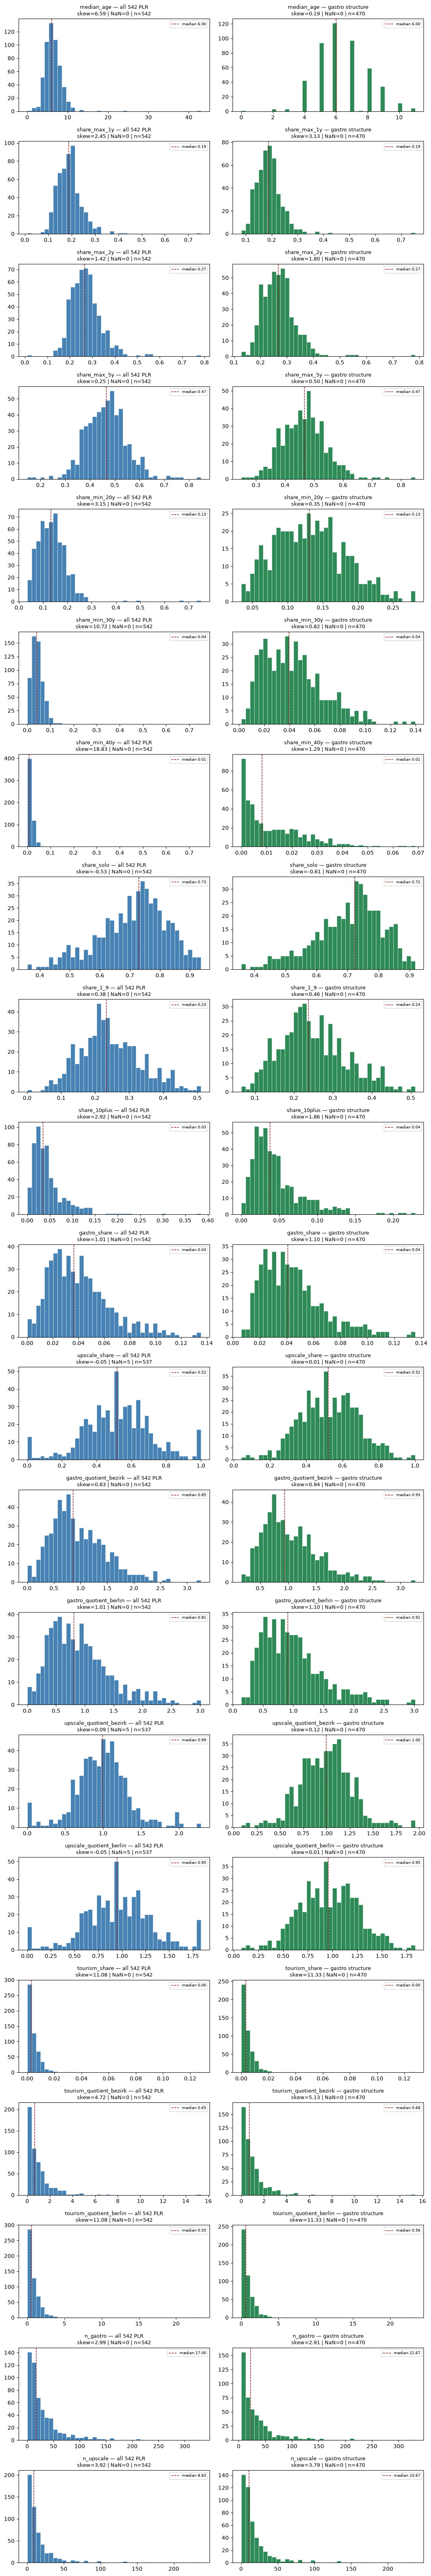

In [13]:
# side-by-side histograms: all 542 PLR (left) vs gastro-structure subset (right)
def hist_pair(col, ax_all, ax_sub):
    for ax, data, label, color in [
        (ax_all, df[col], "all 542 PLR", "steelblue"),
        (ax_sub, cs[col], "gastro structure", "seagreen"),
    ]:
        d = data.dropna()
        ax.hist(d, bins=40, color=color, edgecolor="white", linewidth=0.4)
        if len(d):
            ax.axvline(d.median(), color="darkred", linestyle="--", linewidth=1,
                       label=f"median {d.median():.2f}")
            ax.legend(fontsize=7)
        skew = d.skew() if len(d) > 2 else float("nan")
        n_na = int(data.isna().sum())
        short = col.replace("com_", "").replace("_level_2026", "")
        ax.set_title(f"{short} — {label}\nskew={skew:.2f} | NaN={n_na} | n={len(d)}", fontsize=9)

n = len(level_vars)
fig, axes = plt.subplots(n, 2, figsize=(11, 3.1 * n))
for i, col in enumerate(level_vars):
    hist_pair(col, axes[i, 0], axes[i, 1])
plt.tight_layout()
plt.show()

### Skew overview (compact)

Quick tabular overview — which variables are asymmetric? Description only, no consequence yet.

In [14]:
rows = []
for col in level_vars:
    d_all = df[col].dropna()
    d_sub = cs[col].dropna()
    rows.append({
        "variable": col.replace("com_", ""),
        "skew_all": round(d_all.skew(), 2) if len(d_all) > 2 else np.nan,
        "skew_sub": round(d_sub.skew(), 2) if len(d_sub) > 2 else np.nan,
        "median_all": round(d_all.median(), 3) if len(d_all) else np.nan,
        "NaN_all": int(df[col].isna().sum()),
    })
skew_tab = pd.DataFrame(rows).sort_values("skew_all", key=lambda s: s.abs(), ascending=False)
print(skew_tab.to_string(index=False))

                          variable  skew_all  skew_sub  median_all  NaN_all
          share_min_40y_level_2026     18.83      1.29       0.008        0
tourism_quotient_berlin_level_2026     11.08     11.33       0.552        0
          tourism_share_level_2026     11.08     11.33       0.003        0
          share_min_30y_level_2026     10.72      0.82       0.040        0
             median_age_level_2026      6.59      0.19       6.000        0
tourism_quotient_bezirk_level_2026      4.72      5.13       0.652        0
                         n_upscale      3.92      3.79       8.833        0
          share_min_20y_level_2026      3.15      0.35       0.132        0
                          n_gastro      2.99      2.91      17.000        0
           share_10plus_level_2026      2.92      1.86       0.035        0
           share_max_1y_level_2026      2.45      3.13       0.187        0
           share_max_2y_level_2026      1.42      1.80       0.266        0
 gastro_quot

## Step 2 — Correlation matrix (Spearman)

Computed on the gastro-applicable subset across the level features. Spearman (rank-based)
is robust to the skew/outliers still present in the raw features. The goal is to surface
**redundant variables** — e.g. a quotient that is near-perfectly correlated with its
underlying share — so we can decide which to drop before clustering.

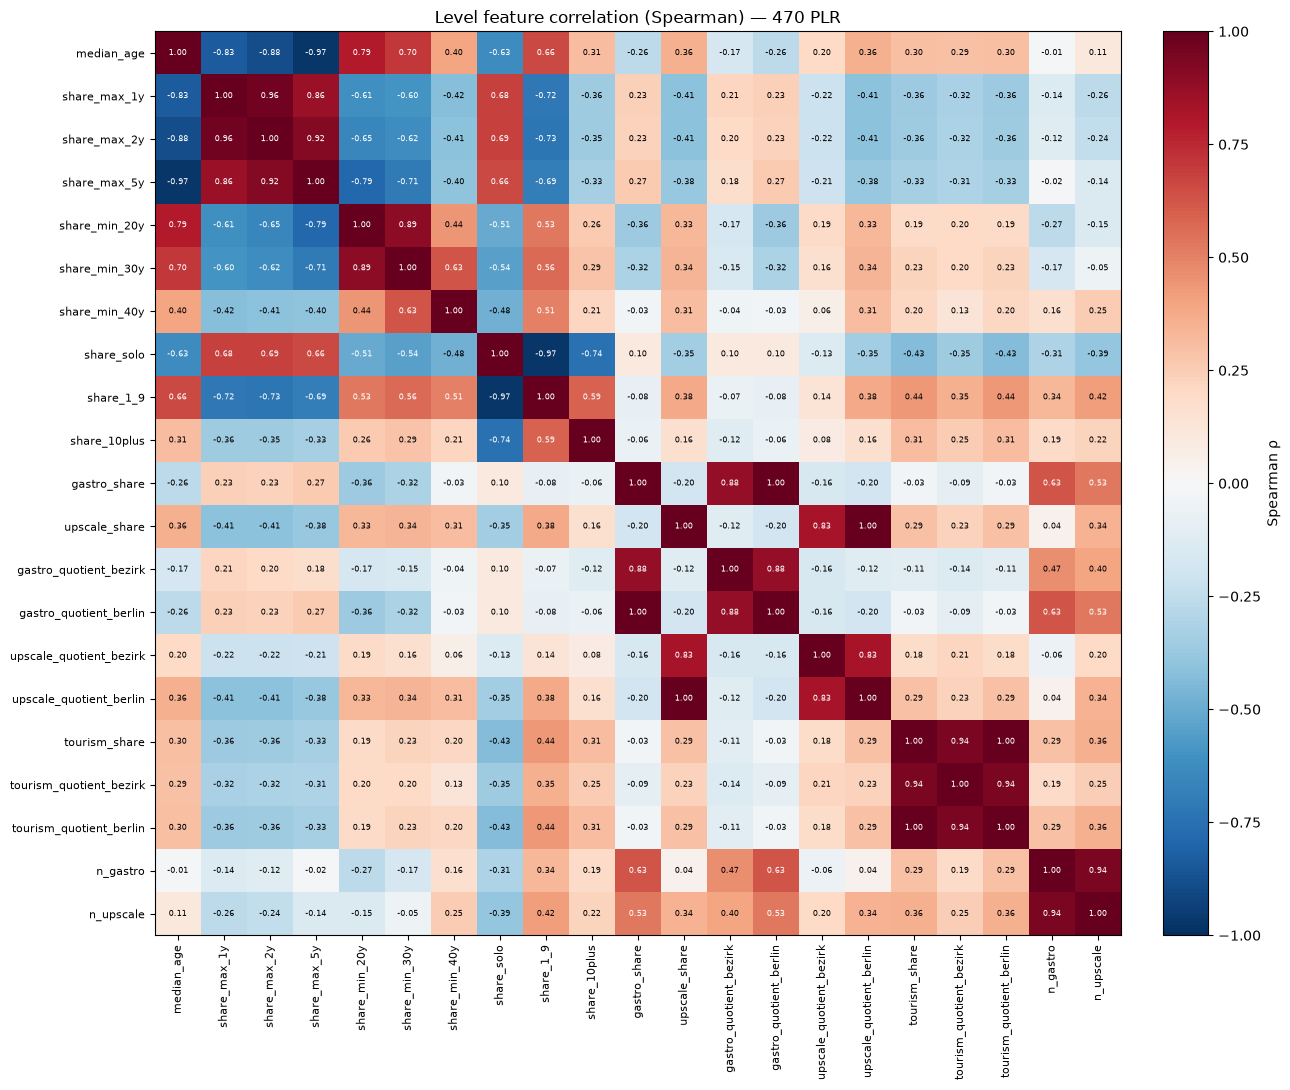

In [15]:
# correlation feature set: levels + raw counts (drop the binary flag; it is not continuous)
corr_cols = level_vars   # already levels + n_gastro/n_upscale

corr = cs[corr_cols].corr(method="spearman")

labels = [c.replace("com_", "").replace("_level_2026", "") for c in corr_cols]
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_cols))); ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(val) > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title(f"Level feature correlation (Spearman) — {len(cs)} PLR", fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# strongest pairs (|rho| > 0.6), excluding self-correlations
print("Strong pairs (|ρ| > 0.6):")
pairs = (corr.where(~np.eye(len(corr), dtype=bool))
             .stack().sort_values(key=abs, ascending=False))
seen = set()
for (a, b), v in pairs.items():
    key = frozenset((a, b))
    if key not in seen and abs(v) > 0.6:
        la = a.replace("com_", "").replace("_level_2026", "")
        lb = b.replace("com_", "").replace("_level_2026", "")
        print(f"  {la:34} {lb:34} {v:+.2f}")
        seen.add(key)

Strong pairs (|ρ| > 0.6):
  upscale_share                      upscale_quotient_berlin            +1.00
  gastro_quotient_berlin             gastro_share                       +1.00
  tourism_quotient_berlin            tourism_share                      +1.00
  share_solo                         share_1_9                          -0.97
  median_age                         share_max_5y                       -0.97
  share_max_1y                       share_max_2y                       +0.96
  n_upscale                          n_gastro                           +0.94
  tourism_quotient_bezirk            tourism_share                      +0.94
  tourism_quotient_bezirk            tourism_quotient_berlin            +0.94
  share_max_5y                       share_max_2y                       +0.92
  share_min_30y                      share_min_20y                      +0.89
  median_age                         share_max_2y                       -0.88
  gastro_share                       g

## Step 3 — Slope correlation (Spearman)

Before adopting the level reduction for the slopes, we check whether the trend variables
show the *same* redundancy structure. A high level correlation does not guarantee a high
slope correlation: two variables can share a static state but move independently over time.

Structural redundancies (Berlin quotients, nested age shares, size shares summing to 1)
must also hold for the slopes by construction. The empirical pairs (e.g. median_age vs.
share_max_2y) are the ones to verify here.

Spearman uses pairwise-complete observations, so the few NaN slopes (the upscale trends
with < 12 valid months) are handled automatically.

In [17]:
# the 19 slope variables (same base variables as the levels)
slope_vars = [
    "com_median_age_slope",
    "com_share_max_1y_slope", "com_share_max_2y_slope", "com_share_max_5y_slope",
    "com_share_min_20y_slope", "com_share_min_30y_slope", "com_share_min_40y_slope",
    "com_share_solo_slope", "com_share_1_9_slope", "com_share_10plus_slope",
    "com_gastro_share_slope", "com_upscale_share_slope",
    "com_gastro_quotient_bezirk_slope", "com_gastro_quotient_berlin_slope",
    "com_upscale_quotient_bezirk_slope", "com_upscale_quotient_berlin_slope",
    "com_tourism_share_slope", "com_tourism_quotient_bezirk_slope",
    "com_tourism_quotient_berlin_slope",
]
print(len(slope_vars), "slope variables")
print("slope NaN counts:")
print(cs[slope_vars].isna().sum()[lambda s: s > 0].to_string() or "  none")

19 slope variables
slope NaN counts:
Series([], )


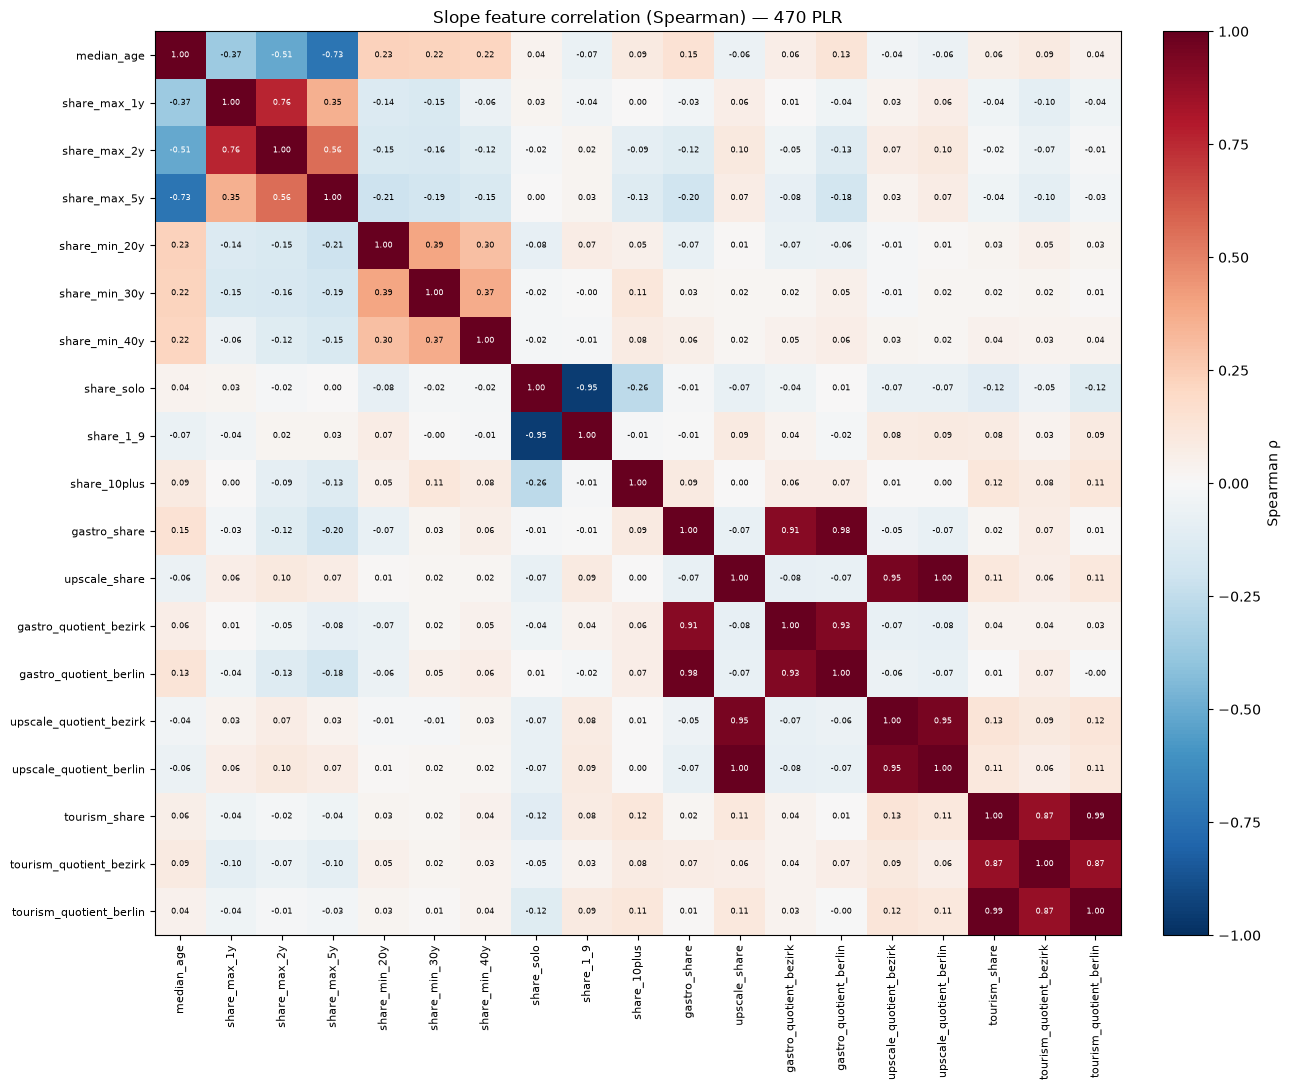

In [18]:
# Spearman heatmap of the slopes (gastro-applicable subset)
corr_s = cs[slope_vars].corr(method="spearman")

labels_s = [c.replace("com_", "").replace("_slope", "") for c in slope_vars]
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_s, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(slope_vars))); ax.set_yticks(range(len(slope_vars)))
ax.set_xticklabels(labels_s, rotation=90, fontsize=8)
ax.set_yticklabels(labels_s, fontsize=8)
for i in range(len(slope_vars)):
    for j in range(len(slope_vars)):
        val = corr_s.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(val) > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title(f"Slope feature correlation (Spearman) — {len(cs)} PLR", fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
# strongest slope pairs (|rho| > 0.6)
print("Strong slope pairs (|ρ| > 0.6):")
pairs_s = (corr_s.where(~np.eye(len(corr_s), dtype=bool))
                 .stack().sort_values(key=abs, ascending=False))
seen = set()
for (a, b), v in pairs_s.items():
    key = frozenset((a, b))
    if key not in seen and abs(v) > 0.6:
        la = a.replace("com_", "").replace("_slope", "")
        lb = b.replace("com_", "").replace("_slope", "")
        print(f"  {la:34} {lb:34} {v:+.2f}")
        seen.add(key)

Strong slope pairs (|ρ| > 0.6):
  upscale_share                      upscale_quotient_berlin            +1.00
  tourism_quotient_berlin            tourism_share                      +0.99
  gastro_share                       gastro_quotient_berlin             +0.98
  upscale_quotient_berlin            upscale_quotient_bezirk            +0.95
  upscale_share                      upscale_quotient_bezirk            +0.95
  share_solo                         share_1_9                          -0.95
  gastro_quotient_berlin             gastro_quotient_bezirk             +0.93
  gastro_share                       gastro_quotient_bezirk             +0.91
  tourism_quotient_berlin            tourism_quotient_bezirk            +0.87
  tourism_share                      tourism_quotient_bezirk            +0.87
  share_max_1y                       share_max_2y                       +0.76
  median_age                         share_max_5y                       -0.73


### Comparison: do the slopes share the level redundancy structure?

Compare the strong slope pairs above with the level pairs from Step 2. For each redundancy
group decided on the levels, check whether the corresponding slopes are correlated to a
similar degree:

- **Berlin quotients vs. shares** — expected ρ ≈ 1.00 (structural, holds for slopes too)
- **nested age shares** (max_1y/2y/5y, min_20y/30y/40y) — expected high (structural)
- **size shares** (solo / 1_9 / 10plus) — expected high (sum = 1, structural)
- **median_age vs. share_max_2y** — empirical; verify whether the trends are as strongly
  related as the levels were

If the structure matches, the same 8-variable reduction is adopted for the slopes. Any
pair that is redundant as a level but independent as a slope is flagged for a closer look.